# Data Sanity Check

This notebook explores the `raw_listings` table from SQLite in order to revise the basic quality of the data.

In [25]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

## Section 1 — Load and overview

Connect to SQLite, load `raw_listings` into a DataFrame, show shape, dtypes, head, counts by source, and counts by timestamp.

In [26]:
import sqlite3
import pandas as pd

db_path = "../data/hardware_pulse.db"
con = sqlite3.connect(db_path)

df = pd.read_sql_query("SELECT * FROM raw_listings", con)
con.close()

print("DataFrame loaded successfully")

df.shape

DataFrame loaded successfully


(344, 15)

In [27]:
df.dtypes

id                      int64
listing_key               str
source                    str
item_id                object
url                       str
timestamp                 str
title                     str
price                 float64
currency                  str
seller                    str
condition                 str
available_quantity     object
base_price             object
created_at                str
updated_at                str
dtype: object

In [28]:
df.head(10)

,id,listing_key,source,item_id,url,timestamp,title,price,currency,seller,condition,available_quantity,base_price,created_at,updated_at
0,1,3091de08fdf533025f6c7283d5ebf51a29f99a4c7aed2d...,thot,None,https://thotcomputacion.com.uy/producto/antec-...,2026-04-24T21:16:19.477725+00:00,Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...,20.00,USD,thot,new,None,None,2026-04-24T21:16:42.631433+00:00,2026-04-24T21:16:42.631433+00:00
1,2,fecd0d9b1e93b8218abc62b72707aadc116c39bf21499e...,thot,None,https://thotcomputacion.com.uy/producto/antec-...,2026-04-24T21:16:19.477725+00:00,Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...,20.00,USD,thot,new,None,None,2026-04-24T21:16:42.633435+00:00,2026-04-24T21:16:42.633435+00:00
2,3,8e83870019e8f85906854d82a94cf0f3ddd34c0afc8d7e...,thot,None,https://thotcomputacion.com.uy/producto/msi-ge...,2026-04-24T21:16:19.477725+00:00,MSI GeForce G210 1Gb Ddr3 LP,44.99,USD,thot,new,None,None,2026-04-24T21:16:42.635328+00:00,2026-04-24T21:16:42.635328+00:00
3,4,4b6ea70e0968d399b2c46d8c92e01e17a02dc501c0b2a5...,thot,None,https://thotcomputacion.com.uy/producto/gpu-bi...,2026-04-24T21:16:19.477725+00:00,GPU Biostar GeForce G210 1Gb GDDR3,44.99,USD,thot,new,None,None,2026-04-24T21:16:42.636340+00:00,2026-04-24T21:16:42.636340+00:00
4,5,96c6abb4fee1cb08fbb532a0e38473c87c423a970875be...,thot,None,https://thotcomputacion.com.uy/producto/biosta...,2026-04-24T21:16:19.477725+00:00,Biostar Radeon RX550 4gb ddr5,125.00,USD,thot,new,None,None,2026-04-24T21:16:42.637338+00:00,2026-04-24T21:16:42.637338+00:00
5,6,70450c88404aa7f549eaf028738ad3a2d451503c8e506e...,thot,None,https://thotcomputacion.com.uy/producto/gpu-pa...,2026-04-24T21:16:19.477725+00:00,GPU Palit GeForce RTX3050 Stormx 6GB DDR6,280.00,USD,thot,new,None,None,2026-04-24T21:16:42.638338+00:00,2026-04-24T21:16:42.638338+00:00
6,7,c3d5e02faf94c70e2b258d49ddbf69bfe12403cda87129...,thot,None,https://thotcomputacion.com.uy/producto/gpu-ms...,2026-04-24T21:16:19.477725+00:00,GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6,285.00,USD,thot,new,None,None,2026-04-24T21:16:42.642339+00:00,2026-04-24T21:16:42.642339+00:00
7,8,721969106e6722c34d16a6d4213b9796094db16d849e89...,thot,None,https://thotcomputacion.com.uy/producto/gpu-gi...,2026-04-24T21:16:19.477725+00:00,GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb,285.00,USD,thot,new,None,None,2026-04-24T21:16:42.643339+00:00,2026-04-24T21:16:42.643339+00:00
8,9,d7c6149d45e69d4b8ded8a5899c60bae15e233078fd97b...,thot,None,https://thotcomputacion.com.uy/producto/gpu-ms...,2026-04-24T21:16:19.477725+00:00,GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6,289.99,USD,thot,new,None,None,2026-04-24T21:16:42.645484+00:00,2026-04-24T21:16:42.645484+00:00
9,10,2aa8f1e949acb8f444679f28ff9f3287437ffbe3b45c64...,thot,None,https://thotcomputacion.com.uy/producto/gpu-as...,2026-04-24T21:16:19.477725+00:00,GPU ASrock Intel Arc A580 Challenger 8Gb DDR6,295.00,USD,thot,new,None,None,2026-04-24T21:16:42.646495+00:00,2026-04-24T21:16:42.646495+00:00


In [29]:
if "source" in df.columns:
    print("Records by source:")
    display(df["source"].value_counts(dropna=False))
else:
    print("Column 'source' does not exist in the DataFrame")

if "timestamp" in df.columns:
    df["run_date"] = pd.to_datetime(df["timestamp"], errors="coerce").dt.date
    print("\nRecords by run date (run_date):")
    display(df["run_date"].value_counts().sort_index())
    print("\nRecords by timestamp:")
    display(df["timestamp"].value_counts(dropna=False).sort_index())
else:
    print("Column 'timestamp' does not exist in the DataFrame")

Records by source:


source
thot       140
banifox    138
pccompu     66
Name: count, dtype: int64


Records by run date (run_date):


run_date
2026-04-24    308
2026-04-26     30
2026-04-28      5
2026-04-29      1
Name: count, dtype: int64


Records by timestamp:


timestamp
2026-04-24T21:16:19.477725+00:00    55
2026-04-24T21:16:42.717811+00:00    83
2026-04-24T21:17:14.168914+00:00    49
2026-04-24T21:17:23.305704+00:00    87
2026-04-24T21:17:33.780498+00:00    34
2026-04-26T21:32:47.740429+00:00    30
2026-04-28T20:00:04.346926+00:00     1
2026-04-28T20:01:03.235461+00:00     1
2026-04-28T20:01:10.446839+00:00     1
2026-04-28T20:01:19.960409+00:00     1
2026-04-28T20:01:27.123169+00:00     1
2026-04-29T20:00:36.027845+00:00     1
Name: count, dtype: int64

## Section 2 — Prices

Explore the `price` column, inspect the distribution by `currency`, plot a histogram/boxplot by `source`, and identify obvious USD outliers.

count     344.000000
mean      529.882471
std       532.082356
min         3.000000
25%       237.500000
50%       426.000000
75%       672.250000
max      6159.000000
Name: price, dtype: float64

Distribution by currency:


currency
USD    344
Name: count, dtype: int64

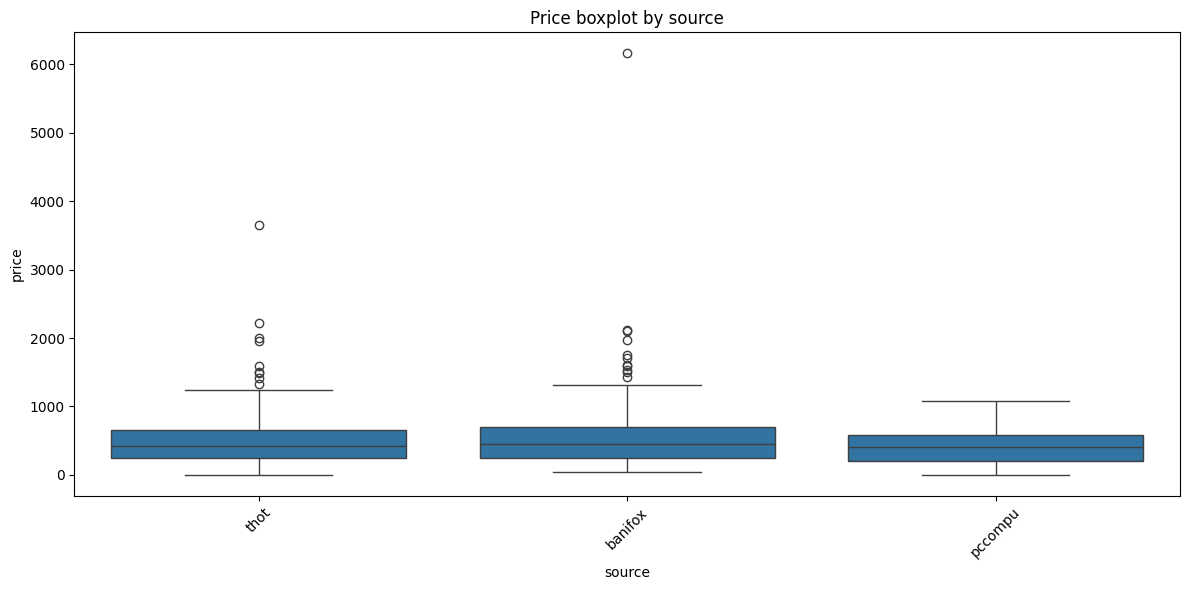

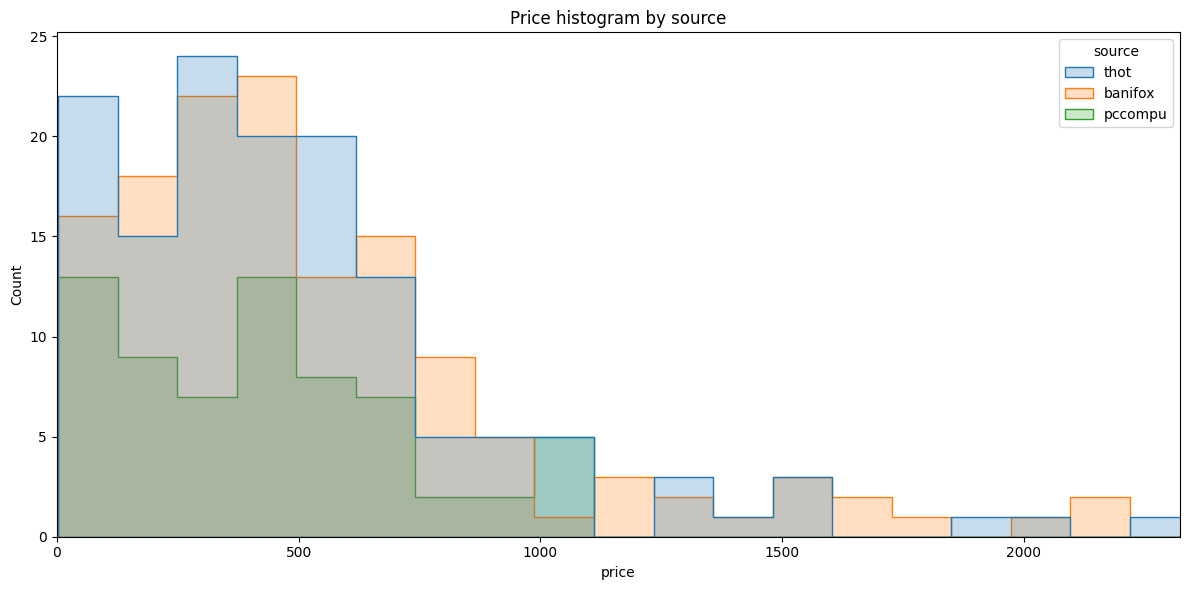

Obvious USD outliers (price < 10 or > 10000): 4 records


,price,currency,source
55,5.0,USD,thot
56,6.0,USD,thot
57,7.0,USD,thot
332,3.0,USD,pccompu


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

price_col = "price"
if price_col in df.columns:
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    display(df[price_col].describe())
else:
    raise KeyError(f"Column {price_col} not found")

if "currency" in df.columns:
    print("Distribution by currency:")
    display(df["currency"].value_counts(dropna=False))
else:
    print("Column 'currency' does not exist in the DataFrame")

if "source" in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="source", y=price_col, data=df)
    plt.title("Price boxplot by source")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x=price_col, hue="source", element="step", stat="count", bins=50, common_norm=False)
    plt.title("Price histogram by source")
    plt.xlim(0, df[price_col].quantile(0.99) * 1.1)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'source' does not exist for plotting prices by source")

usd_mask = df[price_col].notna()
if "currency" in df.columns:
    usd_mask &= df["currency"].astype(str).str.upper() == "USD"

outliers = df.loc[usd_mask & ((df[price_col] < 10) | (df[price_col] > 10000)), [price_col, "currency", "source"] if "source" in df.columns else [price_col, "currency"]]
print(f"Obvious USD outliers (price < 10 or > 10000): {len(outliers)} records")
display(outliers.head(20))

In [31]:
df_component = df[df["price"] >= 43]
len(df_component)

332

## Section 3 — Titles

Extract a sample of 10 titles by source, try to capture the chipset with a simple regex, and count matches.

In [32]:
if "title" not in df.columns:
    raise KeyError("Column 'title' not found in the DataFrame")

pattern = r"RTX\s?\d{4}|RX\s?\d{4}"

if "source" in df.columns:
    for source, group in df.groupby("source"):
        print(f"\nSource: {source}")
        display(group["title"].head(10))
else:
    print("Column 'source' does not exist; showing 10 random titles")
    display(df["title"].sample(10, random_state=42))

matches = df["title"].astype(str).str.contains(pattern, regex=True, case=False, na=False)
print(f"\nTitles matching the pattern '{pattern}': {matches.sum()}")
print(f"Titles NOT matching: {(~matches).sum()}")

sample_matches = df.loc[matches, ["title"]].head(10)
sample_non_matches = df.loc[~matches, ["title"]].head(10)

print("\nExamples of titles with match:")
display(sample_matches)
print("\nExamples of titles without match:")
display(sample_non_matches)


Source: banifox


138            AMD XFX RADEON RX 9070 PRO GAMING 16GB OC
139                               ASUS DUAL-RX9060XT-16G
140    ASUS GEFORCE RTX4070 OC ROG-STRIX-RTX4070-O12G...
141                    ASUS PRIME RADEON RX9070-O16G-EVO
142                             BIOSTAR GEFORCE G210 1GB
143                            BIOSTAR GEFORCE GT610 2GB
144         BIOSTAR RADEON RX550 4GB VA5505RF41SBHRA-BS2
145                 BIOSTAR RADEON RX580 2048SP 8GB DDR5
146    BIOSTAR VIDEO RADEON RX560 4GB VA5615RF41-SBHR...
147         EZDIY-FAB SOPORTE GPU RGB 5V 3 PINES US-3528
Name: title, dtype: str


Source: pccompu


274    Tarjeta de Video Palit StormX Nvidia GeForce R...
275    Tarjeta de Video Biostar AMD Radeon RX 580 8GB...
276    Tarjeta de Video Zotac Nvidia GeForce RTX 5060...
277    Tarjeta de Video Gigabyte AMD Radeon RX 9070 G...
278    Tarjeta de Video Palit Nvidia GeForce RTX 3050...
279    Tarjeta de Video XFX Swift AMD Radeon RX 9060 ...
280    Tarjeta de Video ASRock AMD Radeon RX 9060 XT ...
281    Tarjeta de Video ASRock Intel ARC B580 Challen...
282    Tarjeta de Video Arktek GT 730 4GB DDR3 PCI Ex...
283    Tarjeta de Video Asus Dual GeForce RTX 5060 8G...
Name: title, dtype: str


Source: thot


0    Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...
1    Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...
2                         MSI GeForce G210 1Gb Ddr3 LP
3                   GPU Biostar GeForce G210 1Gb GDDR3
4                        Biostar Radeon RX550 4gb ddr5
5            GPU Palit GeForce RTX3050 Stormx 6GB DDR6
6              GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6
7        GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb
8       GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6
9        GPU ASrock Intel Arc A580 Challenger 8Gb DDR6
Name: title, dtype: str


Titles matching the pattern 'RTX\s?\d{4}|RX\s?\d{4}': 108
Titles NOT matching: 236

Examples of titles with match:


,title
5,GPU Palit GeForce RTX3050 Stormx 6GB DDR6
6,GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6
7,GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb
8,GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6
10,GPU Palit GeForce RTX3050 Dual 8GB DDR6
12,GPU PALIT GeForce RTX 5050 Stormx 8GB
13,GPU ASRock Radeon RX7600 Challenger OC 8Gb
14,GPU MSI GeForce RTX 5050 Shadow 2X OC 8GB
15,GPU Gigabyte Radeon RX7600 Gaming OC 8Gb
16,GPU Gigabyte GeForce RTX5050 Windforce OC 8GB



Examples of titles without match:


,title
0,Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...
1,Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...
2,MSI GeForce G210 1Gb Ddr3 LP
3,GPU Biostar GeForce G210 1Gb GDDR3
4,Biostar Radeon RX550 4gb ddr5
9,GPU ASrock Intel Arc A580 Challenger 8Gb DDR6
11,GPU ASrock Intel Arc B570 Challenger 10Gb DDR6 OC
18,GPU ASrock Intel Arc B580 Challenger 12Gb DDR6 OC
55,Pasta termica Deep Cool Z3
56,Pasta térmica Cooler Master RPD Grease High Pe...


In [33]:
no_match = df[~matches]["title"]
print(no_match.str.contains("RTX|RX|Arc|Radeon|GeForce", case=False).value_counts())

title
False    199
True      37
Name: count, dtype: int64


In [34]:
no_match_gpu = df[~matches & df["title"].str.contains("RTX|RX|Arc|Radeon|GeForce", case=False, na=False)]
print(no_match_gpu["title"].values)

<StringArray>
[                                  'Antec Riser Cable Vertical GPU AT-RCVB-BK200-PCIE4-RTX40',
                                    'Antec Riser Cable Vertical GPU AT-RCVB-W200-PCIE4-RTX40',
                                                               'MSI GeForce G210 1Gb Ddr3 LP',
                                                         'GPU Biostar GeForce G210 1Gb GDDR3',
                                                              'Biostar Radeon RX550 4gb ddr5',
                                              'GPU ASrock Intel Arc A580 Challenger 8Gb DDR6',
                                          'GPU ASrock Intel Arc B570 Challenger 10Gb DDR6 OC',
                                          'GPU ASrock Intel Arc B580 Challenger 12Gb DDR6 OC',
                                                    'CPU AMD Ryzen 3 3200G con Radeon Vega 8',
                                                  'CPU AMD Ryzen 7 5700G con Gráficos Radeon',
                                    

In [35]:
from src.entities.matcher import exact_match, regex_match
from src.entities.catalog import load_catalog

catalog = load_catalog()

titles = [
    "GIGABYTE AMD RADEON R9070XT GV-R907XGAMINGOCICE-16GD",
    "GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6",
    "Tarjeta de Video ASRock Intel ARC B580 Challenger OC 12GB GDDR6 192bit",
    "Antec Riser Cable Vertical GPU AT-RCVB-BK200-PCIE4-RTX40",
    "gigabyte amd radeon 7600",  # Caso 1: falta RX
]

for t in titles:
    print(f"Title:  {t}")
    print(f"Exact:  {exact_match(t, catalog)}")
    print(f"Regex:  {regex_match(t, catalog)}")
    print()

Title:  GIGABYTE AMD RADEON R9070XT GV-R907XGAMINGOCICE-16GD
Exact:  ('RX 9070 XT', 1.0)
Regex:  ('RX 9070 XT', 0.9)

Title:  GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6
Exact:  ('RTX 3050', 1.0)
Regex:  ('RTX 3050', 0.9)

Title:  Tarjeta de Video ASRock Intel ARC B580 Challenger OC 12GB GDDR6 192bit
Exact:  ('Arc B580', 1.0)
Regex:  ('Arc B580', 0.9)

Title:  Antec Riser Cable Vertical GPU AT-RCVB-BK200-PCIE4-RTX40
Exact:  (None, 0.0)
Regex:  (None, 0.0)

Title:  gigabyte amd radeon 7600
Exact:  (None, 0.0)
Regex:  ('RX 7600', 0.9)



In [36]:
# Debug regex_match for the problematic title
test_title = "gigabyte amd radeon 7600"
print(f"Testing: {test_title}")

from src.entities.normalizer import normalize_title, normalize_sku
from src.entities.matcher import _GPU_PATTERNS, _reconstruct_sku_from_match

normalized = normalize_title(test_title)
print(f"Normalized: {normalized}")

for i, pattern in enumerate(_GPU_PATTERNS):
    match = pattern.search(normalized)
    if match:
        print(f"Pattern {i} matched: {match.group(0)}")
        candidate = _reconstruct_sku_from_match(match)
        print(f"Reconstructed: {candidate}")
        candidate_normalized = normalize_sku(candidate)
        print(f"Normalized candidate: {candidate_normalized}")
        
        # Check catalog
        for sku in catalog:
            if normalize_sku(sku) == candidate_normalized:
                print(f"Found match: {sku}")
                break
        else:
            print("No catalog match")
        break
else:
    print("No pattern matched")

Testing: gigabyte amd radeon 7600
Normalized: gigabyte amd radeon 7600
Pattern 2 matched: radeon 7600
Reconstructed: RX 7600
Normalized candidate: rx 7600
Found match: RX 7600


In [37]:
from src.entities.resolver import resolve_batch

# Load actual listings from SQLite
conn = sqlite3.connect("../data/hardware_pulse.db")
df = pd.read_sql_query("SELECT * FROM raw_listings", conn)
conn.close()

# Rebuild RawListing objects
from src.domain.models import RawListing, Source, Currency, Condition

listings = []
for _, row in df.iterrows():
    try:
        listings.append(RawListing(
            source=row["source"],
            url=row["url"],
            timestamp=row["timestamp"],
            title=row["title"],
            price=row["price"],
            currency=row["currency"],
            seller=row["seller"],
            condition=row["condition"],
        ))
    except Exception:
        pass

catalog = load_catalog()
resolved = resolve_batch(listings, catalog)

# Summary
matched = [r for r in resolved if r.canonical_product_id is not None]
unmatched = [r for r in resolved if r.canonical_product_id is None]

print(f"Total:     {len(resolved)}")
print(f"Matched:   {len(matched)}")
print(f"Unmatched: {len(unmatched)}")
print("\nEjemplos sin match:")
for r in unmatched[:10]:
    print(f"  {r.title}")

Total:     344
Matched:   117
Unmatched: 227

Ejemplos sin match:
  Antec Riser Cable Vertical GPU AT-RCVB-BK200-PCIE4-RTX40
  Antec Riser Cable Vertical GPU AT-RCVB-W200-PCIE4-RTX40
  MSI GeForce G210 1Gb Ddr3 LP
  GPU Biostar GeForce G210 1Gb GDDR3
  Biostar Radeon RX550 4gb ddr5
  Pasta termica Deep Cool Z3
  Pasta térmica Cooler Master RPD Grease High Performance
  Pasta termica Deep Cool Z5
  Pasta térmica Deep Cool DM9 1,5g
  Pasta Térmica Cooler Master CRYOFUZE 5


In [38]:
# Test resolver with the fixed case
import sys
for module in list(sys.modules.keys()):
    if module.startswith('src.entities'):
        del sys.modules[module]

from datetime import datetime, timezone
from src.entities.resolver import resolve
from src.entities.catalog import load_catalog

catalog = load_catalog()

# Test Case 2: GV-R906X → RX 9060 XT
test_listing = RawListing(
    source="banifox",
    url="https://example.com",
    timestamp=datetime.now(timezone.utc),
    title="gigabyte amd radeon gv-r906xgamingoceice-16gb",
    price=399.99,
    currency="USD",
    seller="banifox",
)

resolved = resolve(test_listing, catalog)
print("Test Case 2:")
print(f"Title: {test_listing.title}")
print(f"Resolved SKU: {resolved.canonical_product_id}")
print(f"Matched by: {resolved.matched_by}")
print(f"Confidence: {resolved.confidence_score}")

Test Case 2:
Title: gigabyte amd radeon gv-r906xgamingoceice-16gb
Resolved SKU: RX 9060 XT
Matched by: regex
Confidence: 0.9


In [42]:
matched_skus = []
for r in resolved:
    if isinstance(r, tuple):
        sku = r[0]
    else:
        sku = getattr(r, 'canonical_product_id', None)
    if sku is not None:
        matched_skus.append(sku)

from collections import Counter
print(Counter(matched_skus).most_common(15))

[('source', 1), ('url', 1), ('timestamp', 1), ('title', 1), ('price', 1), ('currency', 1), ('seller', 1), ('item_id', 1), ('condition', 1), ('available_quantity', 1), ('base_price', 1), ('canonical_product_id', 1), ('confidence_score', 1), ('matched_by', 1), ('brand', 1)]


In [43]:
conn = sqlite3.connect("../data/hardware_pulse.db")
df = pd.read_sql_query("SELECT * FROM price_snapshots", conn)
conn.close()

print(df.shape)
print(df["canonical_product_id"].value_counts().head(10))

(117, 11)
canonical_product_id
RTX 5060      25
RX 9060 XT    20
RTX 5070      19
RTX 3050      11
RX 9070        8
RTX 5050       7
RX 9070 XT     6
RTX 5080       6
RX 7600        5
Arc A580       2
Name: count, dtype: int64
